# MCMC try 
Neosha from https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial.html

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import pandas as pd
%matplotlib inline
plt.rcParams['figure.figsize'] = (20,10)

In [16]:
ice_data = pd.read_csv('ice_core_data.csv')

In [18]:
ice_data.columns = ["col1", "col2", "col3", "col4", "col5"]

In [27]:
age = ice_data["col3"]
temp_dev = ice_data["col5"]

Text(0.5, 0, 'Age')

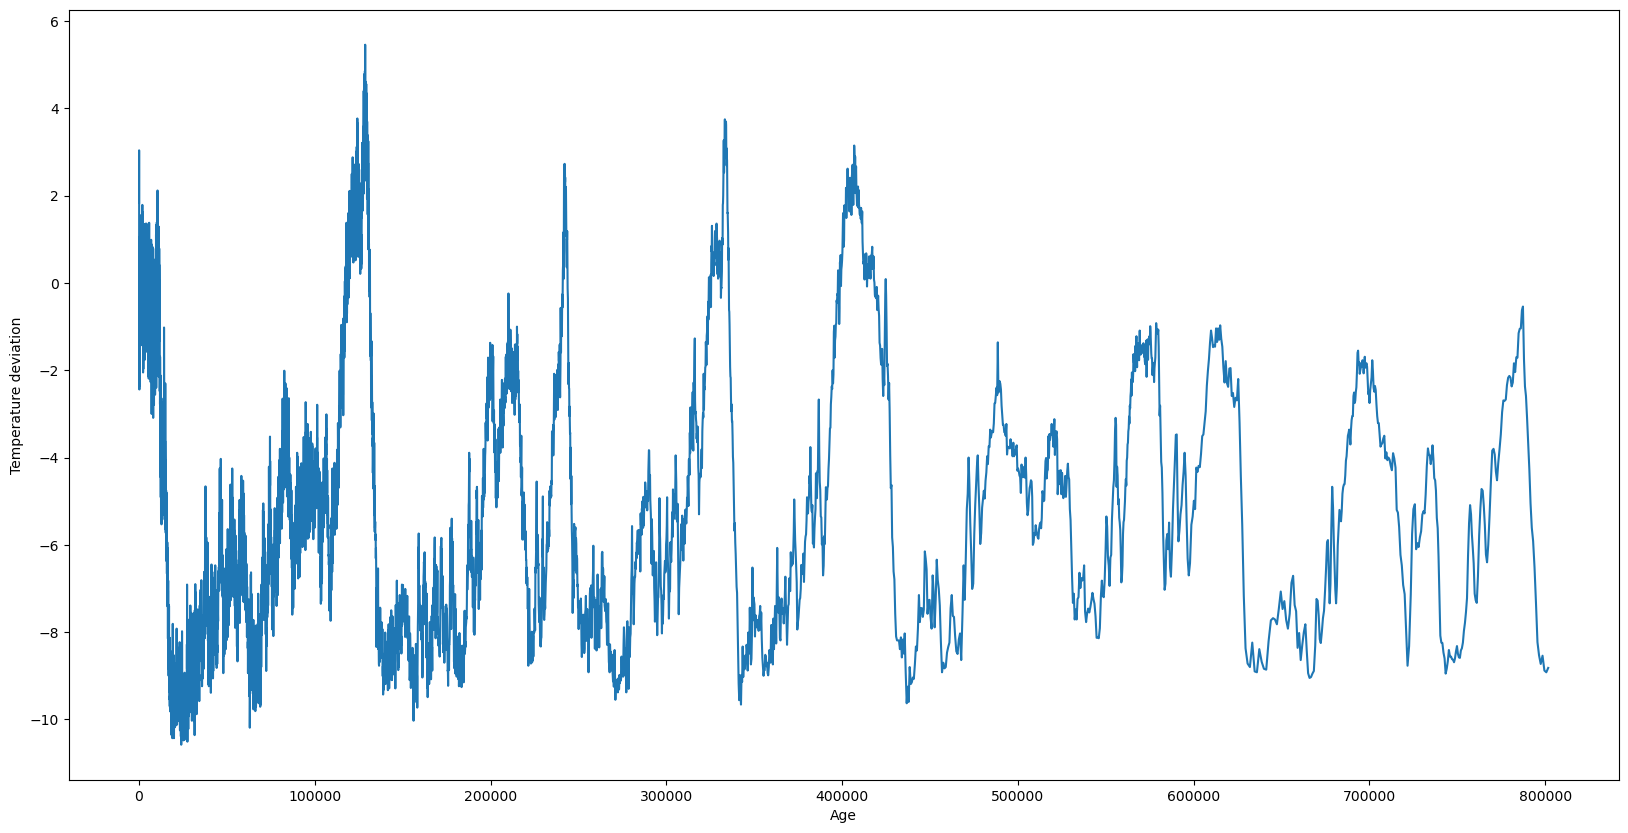

In [28]:
plt.plot(age, temp_dev)
plt.ylabel("Temperature deviation")
plt.xlabel("Age")

Periodic forcing: $\Delta T = a_1 \sin(2 \pi t/p_1) + a_2 \sin(2 \pi t/p_2) + a_3 \sin(2 \pi t/p_3)$ where we will fit for $a_1$, $a_2$, $a_3$, $p_1$, $p_2$, and $p_3$

In [29]:
def model(theta,age=age):
    a1,a2,a3,p1,p2,p3,T0 = theta
    model = a1 * np.sin(2 * pi * age/p1) + a2 * np.sin(2 * pi * age/p2) + a3*np.sin(2*pi*age/p3)
    return model

$L_{lnlike} = -1/2 \sum (\frac{y-y_{model}}{y_{err}})^2$

In [30]:
def lnlike(theta, x, y, yerr):
    y_model = model(theta)
    LnLike = - 0.5 * np.sum((y-y_model)/yerr)#implement formula above
    return LnLike

In [ ]:
def lnprior(theta):
    a1, a2, a3, p1, p2, p3, T0 = theta
    if #apply conditions on priors here
        return 0.0
    else:
        return -np.inf
